In [12]:
import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from meaplotter import MEAPlotter

In [13]:
# ── Config — edit these to match your experiment ─────────────────────────────
FILE_CSV = '/Users/mandarmp/Documents/PHD/HD_MEA_PAPERWITHCDKL5/Fig3/Network_outputs_Canonical/Compiled_Networks.csv'
DIRPATH  = '/Users/mandarmp/Documents/PHD/HD_MEA_PAPERWITHCDKL5/Fig3/Network_outputs_Canonical/plots/'

GROUP_ORDER = ['MxWT', 'FxHET', 'MxHEMI']
PALETTE     = {'MxWT': 'blue', 'FxHET': 'orange', 'MxHEMI': 'red'}

METRICS = [
    'mean_IBI',
    'mean_Burst_Peak',
    'Number_Bursts',
    'mean_Spike_per_Burst',
    'mean_BurstDuration',
]

# Biologically motivated timepoints for stats (DIV 13 = burst peak, 20 = plateau, 27 = mature)
# Only these DIVs enter statistical testing; trajectory plot shows all DIVs for context.
SELECTED_DIVS = [8,16,23,30]

EXCLUDE_LIST = [
    ('M07420', 1), ('M07420', 2), ('M07420', 3),
    ('M07420', 4), ('M07420', 5), ('M07420', 6),
    ('M07427', 3),
]

In [14]:
df_raw = pd.read_csv(FILE_CSV)
df_raw['NeuronType'] = df_raw['NeuronType'].str.strip()
df_raw = df_raw.replace(np.nan, 0.0)
df_raw.head()

,Run_ID,DIV,Assay,Well,NeuronType,Time,Chip_ID,mean_IBI,cov_IBI,mean_Burst_Peak,...,mean_Burst_Peak_Abs,cov_Burst_Peak_Abs,mean_BurstDuration,cov_BurstDuration,BaselineFiringRate,IBI_Distribution,Burst_Peak_Distribution,Abs_Burst_Peak_Distribution,Burst_Duration_Distribution,SpikesPerBurst_Distribution
0,6,5,Network Today,1,MxHEMI,20-May-2024 10:06:26,M07039,23.558333,59.613943,4.102532,...,4200.992680,86.431573,0.823077,0,0.649972,"21.1,7.8,21.9,13.3,54.4,25.4,39.5,32.5,32.1,14...","10.5278,2.5601,1.7589,2.976,2.6257,10.0722,2.1...","10780.4875,2621.4953,1801.0655,3047.4276,2688....","0.8,0.7,0.9,0.8,0.8,0.7,0.8,0.8,0.8,0.9,0.9,1,0.8","9536,2106,1689,2515,2267,8417,1864,9319,1580,1..."
1,6,5,Network Today,2,MxWT,20-May-2024 10:06:26,M07039,0.000000,0.000000,5.500489,...,5632.500735,0.000000,0.700000,0,0.964227,0.0,5.5005,5632.5007,0.7,4516
2,6,5,Network Today,3,FxHET,20-May-2024 10:06:26,M07039,84.150000,1.932675,4.343806,...,4448.057539,3.368602,0.733333,0,0.529309,"83,85.3","4.5056,4.2208,4.305","4613.7646,4322.1097,4408.2983","0.8,0.7,0.7","3856,3438,3630"
3,6,5,Network Today,4,MxHEMI,20-May-2024 10:06:26,M07039,29.377778,65.897720,4.127880,...,4226.948763,73.379444,0.750000,0,0.380034,"24.6,25.7,16.4,30.5,15.3,14.5,44.9,74.2,18.3","8.1916,1.6942,3.9068,2.8138,1.4147,2.5919,8.43...","8388.2179,1734.9011,4000.5722,2881.2932,1448.6...","0.7,0.8,0.7,0.7,0.9,0.7,0.8,0.7,0.7,0.8","7041,1449,3177,2323,1325,2185,7459,1990,7206,1132"
4,6,5,Network Today,5,MxWT,20-May-2024 10:06:26,M07039,0.000000,0.000000,5.632675,...,5767.858828,0.000000,0.800000,0,0.790039,0.0,5.6327,5767.8588,0.8,4773


In [15]:
print("DIVs:   ", sorted(df_raw['DIV'].unique()))
print("Chips:  ", df_raw['Chip_ID'].nunique(), "chips")
print("Groups: ", df_raw['NeuronType'].unique())
print("Shape:  ", df_raw.shape)
print("Columns:", df_raw.columns.tolist())

DIVs:    [5, 8, 13, 16, 20, 23, 27, 30]
Chips:   4 chips
Groups:  ['MxHEMI' 'MxWT' 'FxHET']
Shape:   (186, 25)
Columns: ['Run_ID', 'DIV', 'Assay', 'Well', 'NeuronType', 'Time', 'Chip_ID', 'mean_IBI', 'cov_IBI', 'mean_Burst_Peak', 'cov_Burst_Peak', 'Number_Bursts', 'burstRate', 'mean_Spike_per_Burst', 'cov_Spike_per_Burst', 'mean_Burst_Peak_Abs', 'cov_Burst_Peak_Abs', 'mean_BurstDuration', 'cov_BurstDuration', 'BaselineFiringRate', 'IBI_Distribution', 'Burst_Peak_Distribution', 'Abs_Burst_Peak_Distribution', 'Burst_Duration_Distribution', 'SpikesPerBurst_Distribution']


## Without outlier removal

In [16]:
plotter = MEAPlotter(group_order=GROUP_ORDER, palette=PALETTE)

In [17]:
os.makedirs(DIRPATH, exist_ok=True)
pdf_path = os.path.join(DIRPATH, 'all_plots_meaplotter.pdf')

with PdfPages(pdf_path) as pdf:
    for metric in METRICS:
        plotter.save_pdf(
            df=df_raw,
            y=metric,
            mode='at_timepoints',
            div_col='DIV',
            group_col='NeuronType',
            selected_divs=SELECTED_DIVS,
            title=metric,
            pdf_obj=pdf,
            annotate=True,
            clip_upper=True,
        )

print(f"Saved: {pdf_path}")


==================== STATS (KW + Wilcoxon, BH-FDR): mean_IBI ====================
Selected timepoints: [8, 16, 23, 30]  min_n=3
  DIV 8: KW H=11.118 p=0.0008551 → pairwise tests
  DIV 16: KW H=4.402 p=0.1107 → ns (no pairwise tests)
  DIV 23: KW H=2.164 p=0.339 → ns (no pairwise tests)
  DIV 30: KW H=0.817 p=0.6645 → ns (no pairwise tests)

  BH-FDR: 1/1 pairs significant (q < 0.05)

==================== STATS (KW + Wilcoxon, BH-FDR): mean_Burst_Peak ====================
Selected timepoints: [8, 16, 23, 30]  min_n=3
  DIV 8: KW H=9.751 p=0.001793 → pairwise tests
  DIV 16: KW H=9.696 p=0.007843 → pairwise tests
  DIV 23: KW H=5.934 p=0.05146 → ns (no pairwise tests)
  DIV 30: KW H=5.889 p=0.05263 → ns (no pairwise tests)

  BH-FDR: 3/4 pairs significant (q < 0.05)

==================== STATS (KW + Wilcoxon, BH-FDR): Number_Bursts ====================
Selected timepoints: [8, 16, 23, 30]  min_n=3
  DIV 8: KW H=11.233 p=0.0008034 → pairwise tests
  DIV 16: KW H=4.758 p=0.09262 → ns (no 


==================== STATS (KW + Wilcoxon, BH-FDR): Number_Bursts ====================
Selected timepoints: [8, 16, 23, 30]  min_n=3
  DIV 8: KW H=11.233 p=0.0008034 → pairwise tests
  DIV 16: KW H=4.758 p=0.09262 → ns (no pairwise tests)
  DIV 23: KW H=2.077 p=0.354 → ns (no pairwise tests)
  DIV 30: KW H=0.868 p=0.6478 → ns (no pairwise tests)

  BH-FDR: 1/1 pairs significant (q < 0.05)


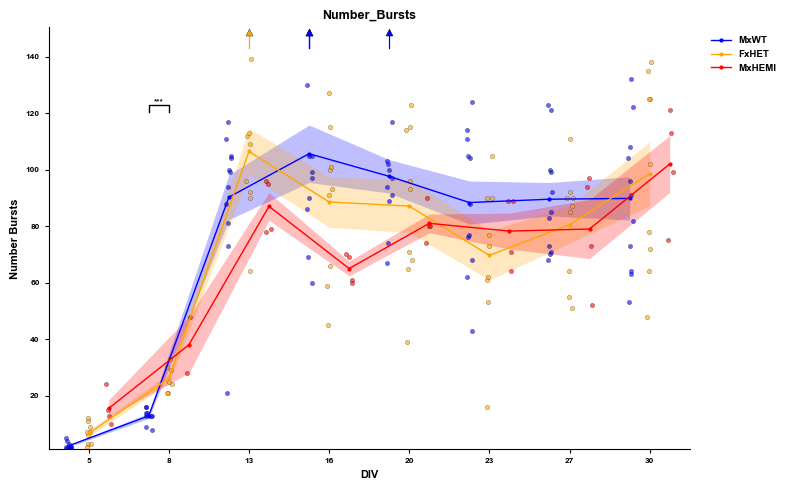

,DIV,group1,group2,comparison,KW_stat,KW_p,W_stat,raw_p,Grp1_Stats,Grp2_Stats,Cohen's d,q_val,reject,Sig
0,8,FxHET,MxHEMI,FxHET vs MxHEMI,11.233284,0.000803,NaN,NaN,26.14 ± 1.75 (n=7),38.00 ± 10.00 (n=2),-1.126760,NaN,False,ns
1,8,MxWT,FxHET,MxWT vs FxHET,11.233284,0.000803,-3.334314,0.000855,12.89 ± 0.92 (n=9),26.14 ± 1.75 (n=7),-3.475435,0.000855,True,***
2,8,MxWT,MxHEMI,MxWT vs MxHEMI,11.233284,0.000803,NaN,NaN,12.89 ± 0.92 (n=9),38.00 ± 10.00 (n=2),-2.464652,NaN,False,ns
3,16,FxHET,MxHEMI,FxHET vs MxHEMI,4.758479,0.092621,NaN,NaN,88.56 ± 8.95 (n=9),65.00 ± 2.61 (n=4),1.217735,NaN,False,ns
4,16,MxWT,FxHET,MxWT vs FxHET,4.758479,0.092621,NaN,NaN,105.64 ± 10.18 (n=11),88.56 ± 8.95 (n=9),0.559939,NaN,False,ns
5,16,MxWT,MxHEMI,MxWT vs MxHEMI,4.758479,0.092621,NaN,NaN,105.64 ± 10.18 (n=11),65.00 ± 2.61 (n=4),1.681985,NaN,False,ns
6,23,FxHET,MxHEMI,FxHET vs MxHEMI,2.076787,0.354023,NaN,NaN,69.67 ± 8.69 (n=9),78.25 ± 6.37 (n=4),-0.418513,NaN,False,ns
7,23,MxWT,FxHET,MxWT vs FxHET,2.076787,0.354023,NaN,NaN,88.36 ± 7.63 (n=11),69.67 ± 8.69 (n=9),0.727764,NaN,False,ns
8,23,MxWT,MxHEMI,MxWT vs MxHEMI,2.076787,0.354023,NaN,NaN,88.36 ± 7.63 (n=11),78.25 ± 6.37 (n=4),0.504641,NaN,False,ns
9,30,FxHET,MxHEMI,FxHET vs MxHEMI,0.868432,0.647772,NaN,NaN,98.56 ± 11.29 (n=9),102.00 ± 10.08 (n=4),-0.123601,NaN,False,ns


In [18]:
# Inline trajectory plot with stats at selected timepoints
# Change `metric` to inspect any column
metric = 'Number_Bursts'

stats = plotter.calculate_stats_at_timepoints(
    df_raw, div_col='DIV', group_col='NeuronType', y=metric,
    selected_divs=SELECTED_DIVS, group_order=GROUP_ORDER,
)

fig, ax = plt.subplots(figsize=(8, 5))
plotter.plot_line_sem_by_div(
    df=df_raw,
    div_col='DIV',
    group_col='NeuronType',
    y=metric,
    title=metric,
    ax=ax,
    annotate=True,
    stats_df=stats,
    clip_upper=True,
    legend_outside=True,
)
plt.tight_layout()
plt.show()

stats


==================== STATS (KW + Wilcoxon, BH-FDR): Number_Bursts ====================
Selected timepoints: [8, 16, 23, 30]  min_n=3
  DIV 8: KW H=11.233 p=0.0008034 → pairwise tests
  DIV 16: KW H=4.758 p=0.09262 → ns (no pairwise tests)
  DIV 23: KW H=2.077 p=0.354 → ns (no pairwise tests)
  DIV 30: KW H=0.868 p=0.6478 → ns (no pairwise tests)

  BH-FDR: 1/1 pairs significant (q < 0.05)


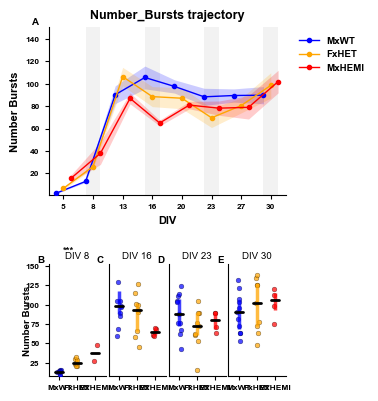

In [19]:
# ── Compact trajectory + DIV 13 / 20 / 27 dot-plots ─────────────────────────
# figsize: 76 mm wide × 107 mm tall (3.0 × 4.2 in), 60:40 height split
metric = 'Number_Bursts'

stats = plotter.calculate_stats_at_timepoints(
    df_raw, div_col='DIV', group_col='NeuronType', y=metric,
    selected_divs=SELECTED_DIVS, group_order=GROUP_ORDER,
)

fig, ax_traj, ax_dots = plotter.plot_trajectory_with_dotplots(
    df=df_raw,
    div_col='DIV',
    group_col='NeuronType',
    y=metric,
    selected_divs=SELECTED_DIVS,   # [13, 20, 27] — bands + panels
    stats_df=stats,
    # title intentionally omitted — metric name lives on the y-axis only
    figsize=(3.0, 4.2),            # 76 mm × 107 mm
    height_ratios=(3, 2),          # 60 % trajectory / 40 % dot plots
    clip_upper=True,
    clip_q=0.98,
    legend_outside=True,
    traj_markers=True,
    dot_size=12,
    label_fontsize=7,
    tick_fontsize=6,               # genotype x-labels match tick size (6 pt)
    panel_label_fontsize=7,
    annotate_traj=False,           # clean trajectory, no day-wise brackets
    show_xtick_labels=True,        # genotype names at 6 pt (set by tick_fontsize)
    show_auc=False,                # AUC goes in supplementary
)

os.makedirs(DIRPATH, exist_ok=True)
fig.savefig(
    os.path.join(DIRPATH, f'{metric}_compact.svg'),
    format='svg', bbox_inches='tight',
)
plt.show()

## With outlier removal

In [20]:
mask = pd.Series([
    (row.Chip_ID, row.Well) in EXCLUDE_LIST
    for _, row in df_raw.iterrows()
])
df_filt = df_raw[~mask].copy()
print(f"Excluded {mask.sum()} rows. Remaining: {len(df_filt)}")
print(df_filt[['Chip_ID', 'Well']].drop_duplicates())

Excluded 56 rows. Remaining: 130
   Chip_ID  Well
0   M07039     1
1   M07039     2
2   M07039     3
3   M07039     4
4   M07039     5
5   M07039     6
12  M07427     1
13  M07427     2
15  M07427     4
16  M07427     5
17  M07427     6
18  M08018     1
19  M08018     2
20  M08018     3
21  M08018     4
22  M08018     5
23  M08018     6


In [21]:
pdf_path_filt = os.path.join(DIRPATH, 'all_plots_filtered_meaplotter.pdf')

with PdfPages(pdf_path_filt) as pdf:
    for metric in METRICS:
        plotter.save_pdf(
            df=df_filt,
            y=metric,
            mode='at_timepoints',
            div_col='DIV',
            group_col='NeuronType',
            selected_divs=SELECTED_DIVS,
            title=f"{metric} (filtered)",
            pdf_obj=pdf,
            annotate=True,
            clip_upper=True,
        )

print(f"Saved: {pdf_path_filt}")


==================== STATS (KW + Wilcoxon, BH-FDR): mean_IBI ====================
Selected timepoints: [8, 16, 23, 30]  min_n=3
  DIV 8: KW H=6.000 p=0.01431 → pairwise tests
  DIV 16: KW H=2.920 p=0.2323 → ns (no pairwise tests)
  DIV 23: KW H=0.254 p=0.8805 → ns (no pairwise tests)
  DIV 30: KW H=2.920 p=0.2323 → ns (no pairwise tests)

  BH-FDR: 1/1 pairs significant (q < 0.05)

==================== STATS (KW + Wilcoxon, BH-FDR): mean_Burst_Peak ====================
Selected timepoints: [8, 16, 23, 30]  min_n=3
  DIV 8: KW H=4.860 p=0.02749 → pairwise tests
  DIV 16: KW H=5.802 p=0.05497 → ns (no pairwise tests)
  DIV 23: KW H=5.706 p=0.05767 → ns (no pairwise tests)
  DIV 30: KW H=3.365 p=0.1859 → ns (no pairwise tests)

  BH-FDR: 1/1 pairs significant (q < 0.05)

==================== STATS (KW + Wilcoxon, BH-FDR): Number_Bursts ====================
Selected timepoints: [8, 16, 23, 30]  min_n=3
  DIV 8: KW H=6.050 p=0.0139 → pairwise tests
  DIV 16: KW H=3.334 p=0.1888 → ns (no pa


==================== STATS (KW + Wilcoxon, BH-FDR): Number_Bursts ====================
Selected timepoints: [8, 16, 23, 30]  min_n=3
  DIV 8: KW H=6.050 p=0.0139 → pairwise tests
  DIV 16: KW H=3.334 p=0.1888 → ns (no pairwise tests)
  DIV 23: KW H=0.255 p=0.8801 → ns (no pairwise tests)
  DIV 30: KW H=3.071 p=0.2153 → ns (no pairwise tests)

  BH-FDR: 1/1 pairs significant (q < 0.05)


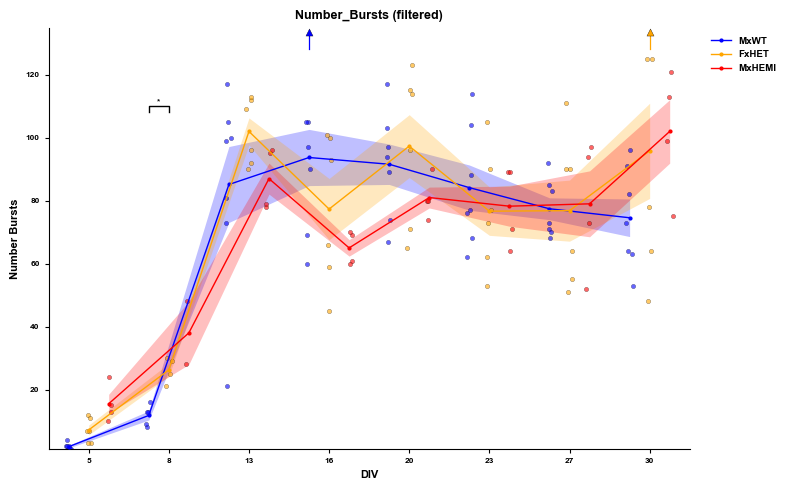

,DIV,group1,group2,comparison,KW_stat,KW_p,W_stat,raw_p,Grp1_Stats,Grp2_Stats,Cohen's d,q_val,reject,Sig
0,8,FxHET,MxHEMI,FxHET vs MxHEMI,6.050420,0.013903,NaN,NaN,26.25 ± 2.06 (n=4),38.00 ± 10.00 (n=2),-1.128253,NaN,False,ns
1,8,MxWT,FxHET,MxWT vs FxHET,6.050420,0.013903,-2.44949,0.014306,11.80 ± 1.46 (n=5),26.25 ± 2.06 (n=4),-3.888635,0.014306,True,*
2,8,MxWT,MxHEMI,MxWT vs MxHEMI,6.050420,0.013903,NaN,NaN,11.80 ± 1.46 (n=5),38.00 ± 10.00 (n=2),-2.552607,NaN,False,ns
3,16,FxHET,MxHEMI,FxHET vs MxHEMI,3.333919,0.188820,NaN,NaN,77.33 ± 9.71 (n=6),65.00 ± 2.61 (n=4),0.716135,NaN,False,ns
4,16,MxWT,FxHET,MxWT vs FxHET,3.333919,0.188820,NaN,NaN,93.71 ± 8.92 (n=7),77.33 ± 9.71 (n=6),0.691264,NaN,False,ns
5,16,MxWT,MxHEMI,MxWT vs MxHEMI,3.333919,0.188820,NaN,NaN,93.71 ± 8.92 (n=7),65.00 ± 2.61 (n=4),1.679555,NaN,False,ns
6,23,FxHET,MxHEMI,FxHET vs MxHEMI,0.255374,0.880129,NaN,NaN,76.67 ± 7.68 (n=6),78.25 ± 6.37 (n=4),-0.098563,NaN,False,ns
7,23,MxWT,FxHET,MxWT vs FxHET,0.255374,0.880129,NaN,NaN,84.14 ± 7.19 (n=7),76.67 ± 7.68 (n=6),0.395310,NaN,False,ns
8,23,MxWT,MxHEMI,MxWT vs MxHEMI,0.255374,0.880129,NaN,NaN,84.14 ± 7.19 (n=7),78.25 ± 6.37 (n=4),0.364157,NaN,False,ns
9,30,FxHET,MxHEMI,FxHET vs MxHEMI,3.071253,0.215321,NaN,NaN,95.83 ± 15.12 (n=6),102.00 ± 10.08 (n=4),-0.206845,NaN,False,ns


In [22]:
# Inline filtered trajectory + stats table
# Change `metric` to inspect
metric = 'Number_Bursts'

stats_filt = plotter.calculate_stats_at_timepoints(
    df_filt, div_col='DIV', group_col='NeuronType', y=metric,
    selected_divs=SELECTED_DIVS, group_order=GROUP_ORDER,
)

fig, ax = plt.subplots(figsize=(8, 5))
plotter.plot_line_sem_by_div(
    df=df_filt,
    div_col='DIV',
    group_col='NeuronType',
    y=metric,
    title=f"{metric} (filtered)",
    ax=ax,
    annotate=True,
    stats_df=stats_filt,
    clip_upper=True,
    legend_outside=True,
)
plt.tight_layout()
plt.show()

stats_filt